In [ ]:
# Etape 2 du projet

In [ ]:
# Importation des bibliothèques

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Chargement du dataset

df = pd.read_csv("payment_fraud.csv")

In [ ]:
# Affichage des 5 

df.head()

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,label
0,29,1,4.745402,paypal,28.204861,0
1,725,1,4.742303,storecredit,0.000000,0
2,845,1,4.921318,creditcard,0.000000,0
3,503,1,4.886641,creditcard,0.000000,0
4,2000,1,5.040929,creditcard,0.000000,0


In [ ]:
# Taille du dataset 

df.shape

(39221, 6)

In [ ]:
# Colonnes du dataset

df.columns

Index(['accountAgeDays', 'numItems', 'localTime', 'paymentMethod',
       'paymentMethodAgeDays', 'label'],
      dtype='str')

In [ ]:
# Types des données 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39221 entries, 0 to 39220
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accountAgeDays        39221 non-null  int64  
 1   numItems              39221 non-null  int64  
 2   localTime             39221 non-null  float64
 3   paymentMethod         39221 non-null  str    
 4   paymentMethodAgeDays  39221 non-null  float64
 5   label                 39221 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 1.8 MB


In [ ]:
# Valeurs manquantes 

df.isnull().sum()

accountAgeDays          0
numItems                0
localTime               0
paymentMethod           0
paymentMethodAgeDays    0
label                   0
dtype: int64

In [ ]:
# Nettoyage des lignes vides 

df = df.dropna()

In [ ]:
# Vérification après nettoyage 

df.shape

(39221, 6)

In [ ]:
# Statistiques générales 

df.describe()

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label
count,39221.000000,39221.000000,39221.000000,39221.000000,39221.000000
mean,857.563984,1.084751,4.748232,122.641326,0.014278
std,804.788212,0.566899,0.389360,283.569177,0.118636
min,1.000000,1.000000,0.421214,0.000000,0.000000
25%,72.000000,1.000000,4.742303,0.000000,0.000000
50%,603.000000,1.000000,4.886641,0.012500,0.000000
75%,1804.000000,1.000000,4.962055,87.510417,0.000000
max,2000.000000,29.000000,5.040929,1999.580556,1.000000


In [ ]:
# Nombres de fraudes / non fraudes

df["label"].value_counts()

label
0    38661
1      560
Name: count, dtype: int64

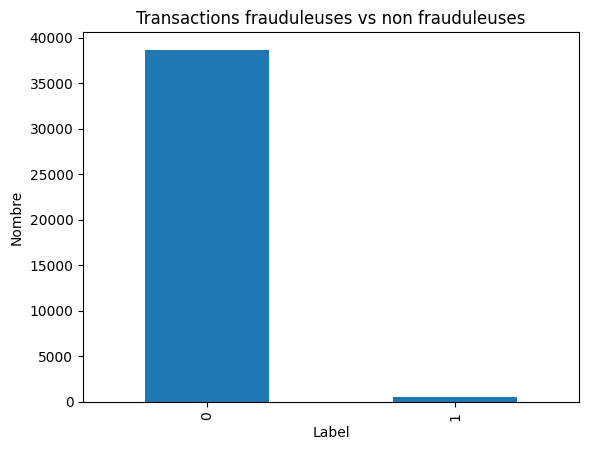

In [ ]:
# Graphiques des fraudes 

df["label"].value_counts().plot(kind="bar")
plt.title("Transactions frauduleuses vs non frauduleuses")
plt.xlabel("Label")
plt.ylabel("Nombre")
plt.show()

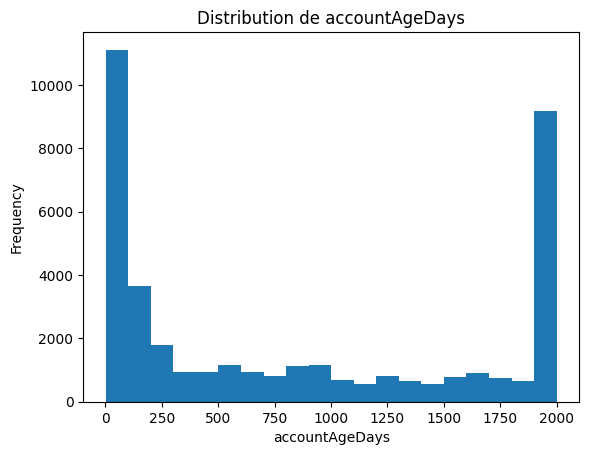

In [ ]:
# Histogramme âge du compte

df["accountAgeDays"].plot(kind="hist", bins=20)
plt.title("Distribution de accountAgeDays")
plt.xlabel("accountAgeDays")
plt.show()

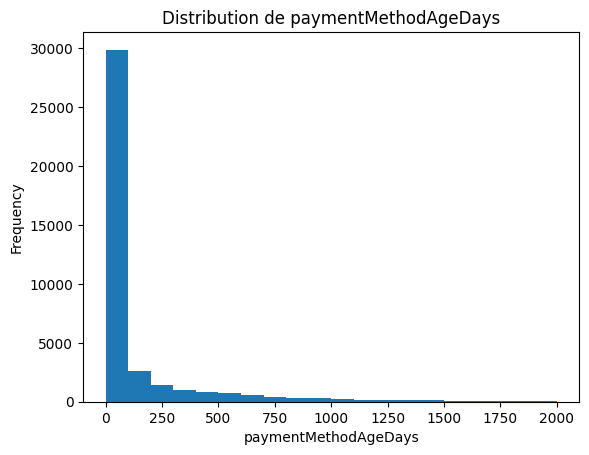

In [ ]:
# Histogramme âge moyen de paiement

df["paymentMethodAgeDays"].plot(kind="hist", bins=20)
plt.title("Distribution de paymentMethodAgeDays")
plt.xlabel("paymentMethodAgeDays")
plt.show()

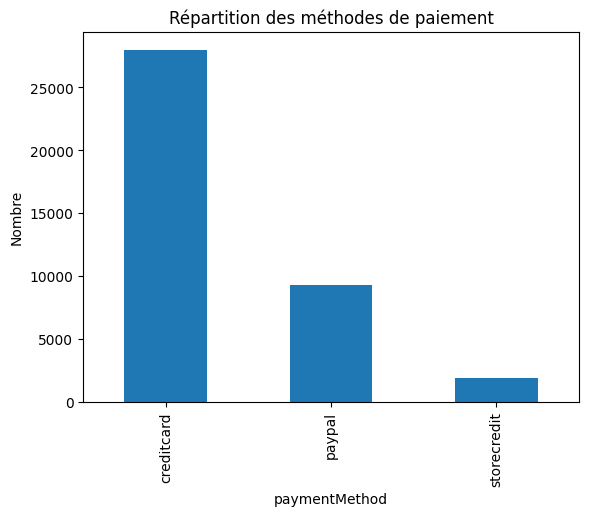

In [ ]:
# Répartition des méthodes de paiement 

df["paymentMethod"].value_counts().plot(kind="bar")
plt.title("Répartition des méthodes de paiement")
plt.xlabel("paymentMethod")
plt.ylabel("Nombre")
plt.show()

### Résumé des colonnes importantes

- accountAgeDays : âge du compte en jours  
- numItems : nombre d’articles dans la transaction  
- localTime : heure de la transaction  
- paymentMethod : méthode de paiement utilisée  
- paymentMethodAgeDays : âge du moyen de paiement  
- label : 0 = non fraude, 1 = fraude  

In [ ]:
# Etape 3 du projet 

In [ ]:
# Importation des bibliothèques 

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

In [ ]:
# Séparations des variables (X) et la cible (y)

X = df.drop("label", axis=1)
y = df["label"]

In [ ]:
# Conversion des colonnes non numériques 

X = pd.get_dummies(X)

In [ ]:
# Séparons train / test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Choix du modèle

Nous avons choisi un modèle d’arbre de décision pour la détection de fraude.

L’arbre de décision est un algorithme simple et efficace pour les problèmes de classification.
Il permet de distinguer les transactions frauduleuses des transactions normales.

In [ ]:
# Création du modèle

model = DecisionTreeClassifier(max_depth=5)

In [ ]:
# Entraîner le modèle

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
# prédiction du modèle

y_pred = model.predict(X_test)

In [ ]:
# Accuracy 

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 1.0


In [ ]:
# Matrice de confusion 

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix :")
print(cm)

Confusion Matrix :
[[7727    0]
 [   0  118]]


In [ ]:
# Sauvegarde du modèle

joblib.dump(model, "model_fraude.pkl")

['model_fraude.pkl']

### Conclusion

Nous avons utilisé un modèle d’arbre de décision pour détecter les transactions frauduleuses.
Le modèle a été entraîné, testé, puis évalué avec l’accuracy et la matrice de confusion.
Enfin, le modèle entraîné a été sauvegardé dans un fichier `model_fraude.pkl`.